# 01. Track / Artist frequency와 Playlist concentration

집계는 `python -m src.aggregate` 가 이미 끝낸 상태여야 한다.
이 노트북은 그림을 보고 **다음 질문**을 정하기 위한 것이다.

항상 같이 볼 것:

1. 이 데이터 자체에 문제적 현상이 있는가?
2. 정상적인 특성이라도, 추천에 그대로 쓰면 문제가 생길 수 있는가?

Head / Mid / Tail 정의: unique track을 `n_playlists` 내림차순으로 줄 세운 뒤 **상위 10% / 다음 40% / 하위 50%**.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

HERE = Path.cwd()
if (HERE / "data" / "processed").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed").exists():
    ROOT = HERE.parent
else:
    ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

In [2]:
summary_path = PROCESSED / "frequency_summary.json"
if not summary_path.exists():
    raise FileNotFoundError("집계 결과가 없습니다. 먼저 `python -m src.aggregate` 를 실행하세요.")

summary = json.loads(summary_path.read_text(encoding="utf-8"))
tracks = pd.read_parquet(PROCESSED / "track_freq.parquet")
artists = pd.read_parquet(PROCESSED / "artist_freq.parquet")
playlists = pd.read_parquet(PROCESSED / "playlist_meta.parquet")
comp = pd.read_parquet(PROCESSED / "playlist_composition.parquet")

n_pl = summary["n_playlists"]
print(f"playlists={n_pl:,}  tracks={summary['n_unique_tracks']:,}  "
      f"artists={summary['n_unique_artists']:,}  interactions={summary['n_interactions']:,}")
if n_pl < 1_000_000:
    print(f"경고: 전체 100만이 아니라 {n_pl:,}개만 집계된 결과입니다.")

playlists=1,000,000  tracks=2,262,292  artists=295,860  interactions=66,346,428


## A. Track 등장 분포

질문: **극단적인 Long-tail인가?**

여기서 멈추면 "MPD는 Long-tail이다"가 된다. 숫자가 나온 뒤 다음 칸으로 간다.

In [3]:
t = summary["track"]
print(f"Gini(n_playlists) = {t['gini_n_playlists']:.3f}")
print(f"top  1% tracks → {t['top_1pct_interaction_share']:.1%} of interactions")
print(f"top 10% tracks → {t['top_10pct_interaction_share']:.1%} of interactions")
print("tier interaction share:", {k: round(v, 3) for k, v in t["tier_interaction_share"].items()})
print(f"median n_playlists = {t['median_n_playlists']:.1f}   mean = {t['mean_n_playlists']:.1f}")

Gini(n_playlists) = 0.921
top  1% tracks → 66.8% of interactions
top 10% tracks → 90.8% of interactions
tier interaction share: {'head': 0.908, 'mid': 0.074, 'tail': 0.018}
median n_playlists = 2.0   mean = 28.9


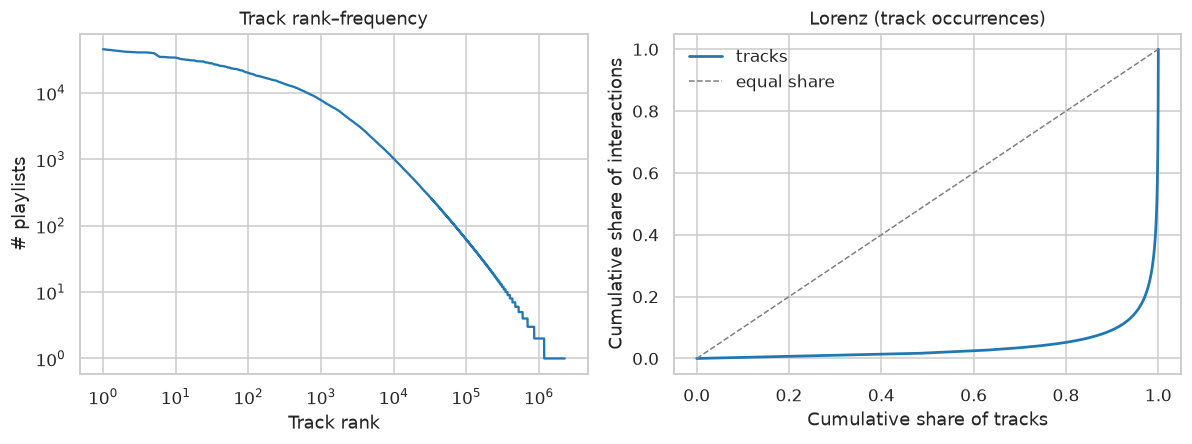

In [4]:
def rank_freq(counts: np.ndarray):
    freq = np.sort(counts)[::-1]
    rank = np.arange(1, freq.size + 1)
    return rank, freq

def lorenz(counts: np.ndarray):
    x = np.sort(counts.astype(np.float64))
    pop = np.linspace(0, 1, x.size)
    cum = np.cumsum(x) / x.sum()
    return pop, cum

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

rank, freq = rank_freq(tracks["n_playlists"].to_numpy())
axes[0].loglog(rank, freq, color="#1f77b4", lw=1.5)
axes[0].set_xlabel("Track rank")
axes[0].set_ylabel("# playlists")
axes[0].set_title("Track rank–frequency")

pop, cum = lorenz(tracks["n_occurrences"].to_numpy())
axes[1].plot(pop, cum, color="#1f77b4", lw=1.8, label="tracks")
axes[1].plot([0, 1], [0, 1], ls="--", c="gray", lw=1, label="equal share")
axes[1].set_xlabel("Cumulative share of tracks")
axes[1].set_ylabel("Cumulative share of interactions")
axes[1].set_title("Lorenz (track occurrences)")
axes[1].legend(frameon=False)

fig.tight_layout()

상위 트랙 예시. 해석용이지, 여기서 카테고리 분석으로 새지 않는다.

In [5]:
tracks.nlargest(15, "n_playlists")[
    ["rank", "track_name", "artist_name", "n_playlists", "n_occurrences", "tier"]
]

,rank,track_name,artist_name,n_playlists,n_occurrences,tier
0,1,HUMBLE.,Kendrick Lamar,45394,46574,head
1,2,One Dance,Drake,41707,43447,head
2,3,Broccoli (feat. Lil Yachty),DRAM,40659,41309,head
3,4,Closer,The Chainsmokers,40629,41079,head
4,5,Congratulations,Post Malone,39577,39987,head
5,6,Caroline,Aminé,34765,35202,head
6,7,iSpy (feat. Lil Yachty),KYLE,34672,35138,head
7,8,Bad and Boujee (feat. Lil Uzi Vert),Migos,34157,34999,head
8,9,XO TOUR Llif3,Lil Uzi Vert,34048,34922,head
9,10,Location,Khalid,33954,34657,head


## A'. Artist 등장 분포

같은 질문을 아티스트에도 던진다. Track보다 집중이 더 센지는 이후 추천 편향을 볼 때 단서가 된다.

In [6]:
a = summary["artist"]
print(f"Gini(n_playlists) = {a['gini_n_playlists']:.3f}")
print(f"top  1% artists → {a['top_1pct_interaction_share']:.1%} of interactions")
print(f"top 10% artists → {a['top_10pct_interaction_share']:.1%} of interactions")

Gini(n_playlists) = 0.964
top  1% artists → 79.8% of interactions
top 10% artists → 96.9% of interactions


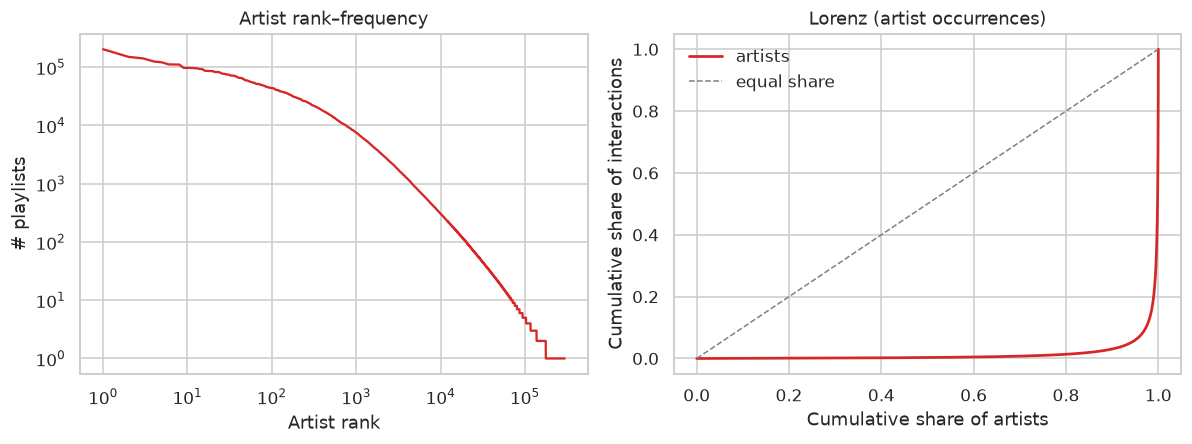

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

rank, freq = rank_freq(artists["n_playlists"].to_numpy())
axes[0].loglog(rank, freq, color="#d62728", lw=1.5)
axes[0].set_xlabel("Artist rank")
axes[0].set_ylabel("# playlists")
axes[0].set_title("Artist rank–frequency")

pop, cum = lorenz(artists["n_occurrences"].to_numpy())
axes[1].plot(pop, cum, color="#d62728", lw=1.8, label="artists")
axes[1].plot([0, 1], [0, 1], ls="--", c="gray", lw=1, label="equal share")
axes[1].set_xlabel("Cumulative share of artists")
axes[1].set_ylabel("Cumulative share of interactions")
axes[1].set_title("Lorenz (artist occurrences)")
axes[1].legend(frameon=False)

fig.tight_layout()

## B. Playlist 단위 concentration

질문: **이 불균형이 모든 플레이리스트에서 동일한가?**

- 분포가 한곳에 모여 있으면 → 전역 불균형이 공통 특성. 추천에서 증폭되는지만 보면 된다.
- 분포가 넓으면 → "왜 어떤 플리는 Head, 어떤 플리는 Tail인가?" 가 다음 질문이다.

지금은 Followers/Edits 상관을 깔지 않는다.

In [8]:
p = summary["playlist_composition"]
print("Head Ratio  mean={:.3f}  std={:.3f}  p10={:.3f}  p50={:.3f}  p90={:.3f}".format(
    p["head_ratio_mean"], p["head_ratio_std"], p["head_ratio_p10"], p["head_ratio_p50"], p["head_ratio_p90"]))
print("Tail Ratio  mean={:.3f}  std={:.3f}  p10={:.3f}  p50={:.3f}  p90={:.3f}".format(
    p["tail_ratio_mean"], p["tail_ratio_std"], p["tail_ratio_p10"], p["tail_ratio_p50"], p["tail_ratio_p90"]))

Head Ratio  mean=0.909  std=0.169  p10=0.726  p50=0.979  p90=1.000
Tail Ratio  mean=0.018  std=0.066  p10=0.000  p50=0.000  p90=0.042


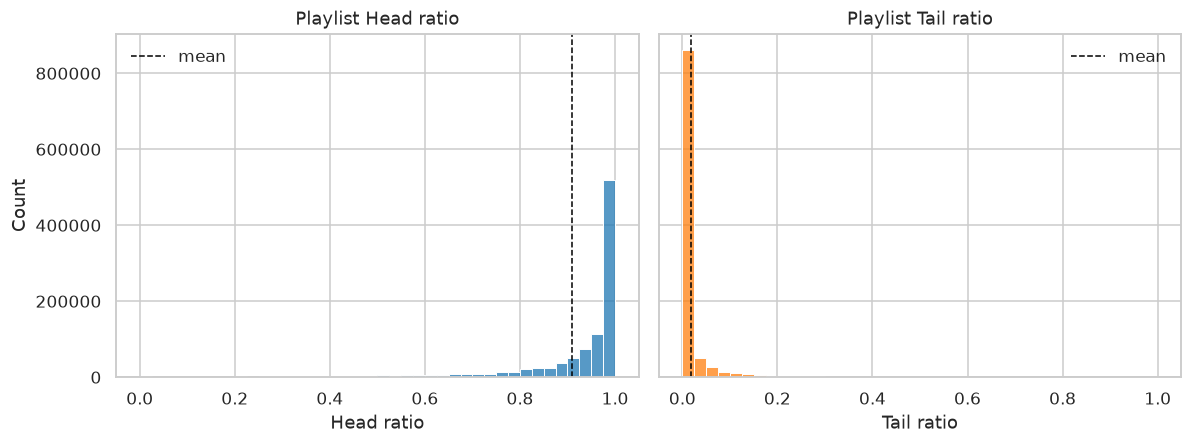

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
sns.histplot(comp["head_ratio"].dropna(), bins=40, ax=axes[0], color="#1f77b4")
axes[0].axvline(p["head_ratio_mean"], color="black", ls="--", lw=1, label="mean")
axes[0].set_xlabel("Head ratio")
axes[0].set_title("Playlist Head ratio")
axes[0].legend(frameon=False)

sns.histplot(comp["tail_ratio"].dropna(), bins=40, ax=axes[1], color="#ff7f0e")
axes[1].axvline(p["tail_ratio_mean"], color="black", ls="--", lw=1, label="mean")
axes[1].set_xlabel("Tail ratio")
axes[1].set_title("Playlist Tail ratio")
axes[1].legend(frameon=False)

fig.tight_layout()

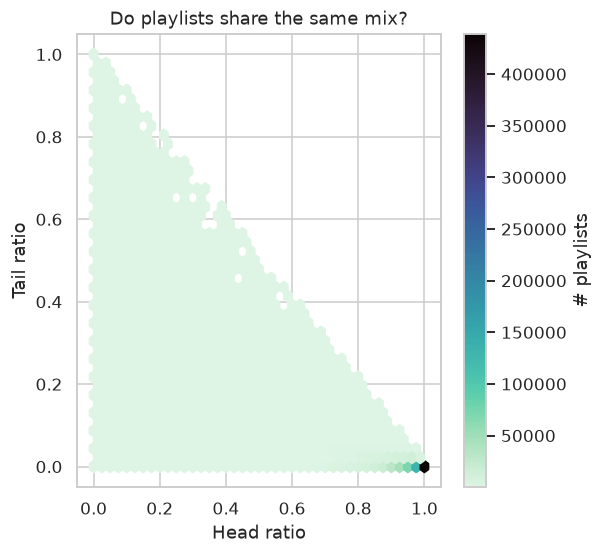

In [10]:
fig, ax = plt.subplots(figsize=(5.6, 5.2))
hb = ax.hexbin(
    comp["head_ratio"],
    comp["tail_ratio"],
    gridsize=40,
    cmap="mako_r",
    mincnt=1,
)
ax.set_xlabel("Head ratio")
ax.set_ylabel("Tail ratio")
ax.set_title("Do playlists share the same mix?")
fig.colorbar(hb, ax=ax, label="# playlists")
fig.tight_layout()

길이로만 갈리는 착시인지는 **분산이 클 때만** 본다. 짧아서 Head처럼 보이거나, 길어서 평균으로 회귀하는지만 확인한다.

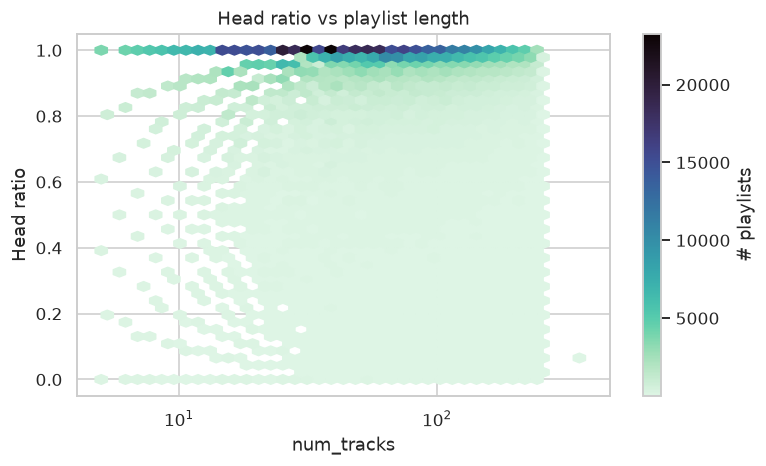

In [11]:
merged = comp.merge(playlists[["pid", "num_tracks"]], on="pid", how="left")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
hb = ax.hexbin(
    merged["num_tracks"],
    merged["head_ratio"],
    gridsize=40,
    cmap="mako_r",
    mincnt=1,
    xscale="log",
)
ax.set_xlabel("num_tracks")
ax.set_ylabel("Head ratio")
ax.set_title("Head ratio vs playlist length")
fig.colorbar(hb, ax=ax, label="# playlists")
fig.tight_layout()

## 이 노트북에서 결정할 것

그림을 보고 아래 중 어디에 가까운지 고른다.

| 결과 | 다음 질문 |
|---|---|
| Head/Tail ratio가 플리마다 거의 같음 | 전역 Long-tail이 추천에서 증폭되는가? (경로 B 후보) |
| 플리마다 비율이 크게 갈림 | 왜 어떤 플리는 Head, 어떤 플리는 Tail인가? |
| 차이는 있지만 길이로 거의 설명됨 | 길이를 통제한 뒤에도 남는 차이가 있는가? |

**목적 제목 라벨은 여기서 강제하지 않는다.** Long-tail 여부와 플리 간 분산은 제목 없이도 답할 수 있다.

아래 칸은 **B에서 분산이 클 때만** 연다. 가설은 "목적형 플리(운동, 수면 등)와 비목적 플리가 다른 mix를 갖는가?" 이다. 제목 노이즈가 있으니 `confidence == high` 만 쓰고, 카테고리 세분화는 아직 하지 않는다.

다음 노트북은 그 답이 나온 뒤에 만든다.

## (선택) 목적형 제목으로 mix가 갈리는가

A/B를 보기 전에는 실행하지 않는다. Head/Tail ratio 분산이 클 때, 길이 다음 설명 후보로만 본다.


In [12]:
labels_path = ROOT / "purpose_titles" / "outputs" / "all_unique_purpose_labels.csv"
if not labels_path.exists():
    raise FileNotFoundError(f"목적 라벨이 없습니다: {labels_path}")

labels = pd.read_csv(labels_path, usecols=["name_key", "has_purpose", "confidence"])
pl = playlists[["pid", "name"]].copy()
pl["name_key"] = pl["name"].fillna("").str.strip().str.lower()
pl = pl.merge(labels, on="name_key", how="left")

# 제목 노이즈를 줄이기 위해 high confidence만
pl["purpose_group"] = np.where(
    (pl["has_purpose"] == "yes") & (pl["confidence"] == "high"),
    "purpose",
    np.where(pl["has_purpose"] == "no", "non_purpose", "other"),
)

purpose_comp = comp.merge(pl[["pid", "purpose_group"]], on="pid", how="left")
purpose_comp = purpose_comp[purpose_comp["purpose_group"].isin(["purpose", "non_purpose"])]

purpose_comp.groupby("purpose_group")[["head_ratio", "tail_ratio"]].agg(
    ["count", "mean", "std", "median"]
)

head_ratio                               tail_ratio            \
                   count      mean       std    median      count      mean   
purpose_group                                                                 
non_purpose       771703  0.904474  0.175171  0.977778     771703  0.018880   
purpose           186939  0.925489  0.145392  0.982301     186939  0.013993   

                                
                    std median  
purpose_group                   
non_purpose    0.068288    0.0  
purpose        0.056140    0.0

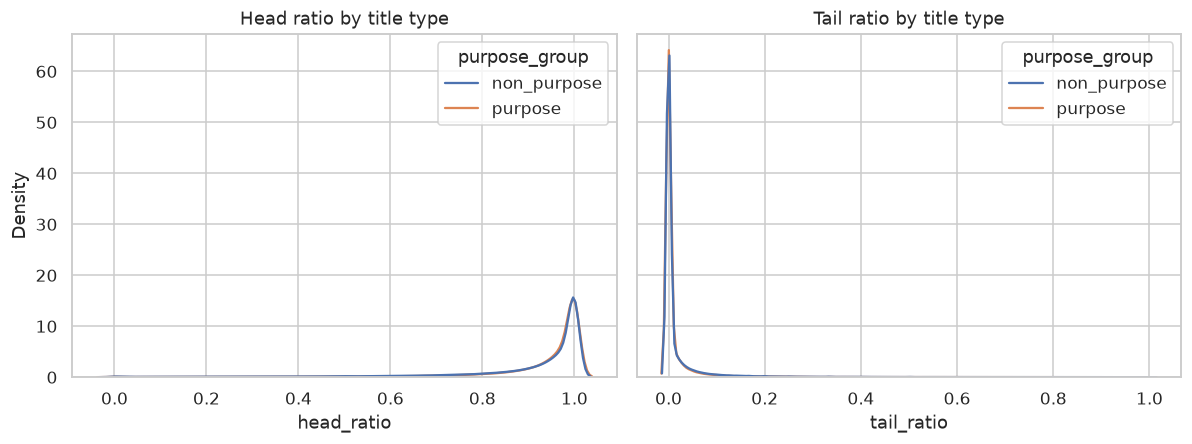

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, col, title in zip(
    axes,
    ["head_ratio", "tail_ratio"],
    ["Head ratio by title type", "Tail ratio by title type"],
):
    sns.kdeplot(
        data=purpose_comp,
        x=col,
        hue="purpose_group",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(title)
fig.tight_layout()

# 두 분포가 거의 겹치면 목적 제목은 이 단계의 설명 변수가 아니다.
# 갈리면 길이 통제 후에도 남는지가 다음 질문이다.